# RQ1 - the answer

This notebook computes nothing new. It reads what notebooks A, B, C and D measured and
answers the two halves of RQ1:

1. **how** retrieval strategy, chunking method and reranking affect the multi-metric profile;
2. **which of the three carries the largest main effect.**

### How "largest main effect" is decided
For each factor and each metric the level means are computed over the questions that every
level scored, so the comparison is paired. The effect is then summarised three ways, because
no single summary is safe on its own:

* **range** - the spread of the level means, in the metric's own units;
* **standardised range** - that spread divided by the between-question standard deviation, so
  metrics on different scales can be averaged;
* **partial eta squared** - the share of variance the factor explains once question difficulty
  is removed, from the repeated-measures decomposition.

The raw range flatters a factor with more levels: a five-level factor has more chances to
produce an extreme mean than a two-level one. The **matched contrast** is therefore also
reported - each factor's best level minus its own centre-point level, which gives every
factor exactly two levels and makes the ranking level-count independent. If the two orderings
disagree, that disagreement is the finding and is reported as such.

Everything is Holm-corrected across factors within each metric.

## 1. Open the shared cache

In [1]:
# Load the shared library written by notebook 00 and open the same cache.
import sys, os
from google.colab import drive
drive.mount('/content/drive')
PROJECT = '/content/drive/MyDrive/techqa_rq1'
assert os.path.exists(PROJECT + '/rq1_core.py'), (
    'rq1_core.py not found. Run RQ1_00_Build_Once.ipynb first - it writes the library '
    'and builds the chunk tables and embeddings that this notebook reads from cache.')
sys.path.insert(0, PROJECT)
import rq1_core as C
import numpy as np, pandas as pd, time, json
C.setup(project_dir=PROJECT)
print('GPU:', C.gpu_name())

Mounted at /content/drive
rq1_core 1.1 | profile=fast | run tag u512_o10_p0
  cache   -> /content/drive/MyDrive/techqa_rq1/cache_u512_o10_p0
  outputs -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0
GPU: Tesla T4


## 2. Load what A, B, C and D measured

In [2]:
A = C.load_table('rq1_factorA_per_question')
B = C.load_table('rq1_factorB_per_question')
Cf = C.load_table('rq1_factorC_per_question')
G = C.load_table('rq1_generation_scored')
for name, t in [('A chunking', A), ('B retrieval', B), ('C reranking', Cf),
                ('D generation', G)]:
    print(f'{name:<16} {"missing - run that notebook" if t is None else f"{len(t):>6,} rows"}')
assert A is not None and B is not None and Cf is not None, \
    'factors A, B and C are all required'
if G is None:
    print('\nNote: without notebook D the answer covers the retrieval half of the profile only.')

A chunking        3,660 rows
B retrieval       2,440 rows
C reranking       1,220 rows
D generation      2,651 rows


## 3. The main effect of every factor on every metric

The chunking frame is restricted to the five methods of Table 2.2; the matched long-context control is a diagnostic for late chunking, not a level of the factor, so including it would inflate the factor's range.

In [3]:
A5 = A[A.method.isin(C.CFG.CHUNK_METHODS)]
frames = {'chunking_method':    (A5, 'method'),
          'retrieval_strategy': (B,  'retriever'),
          'reranking':          (Cf, 'rerank_level')}
baselines = {'chunking_method': C.CFG.BASELINE_METHOD,
             'retrieval_strategy': C.CFG.BASELINE_RETRIEVER,
             'reranking': 'off'}
PROFILE_METRICS = list(C.RETRIEVAL_METRICS)

if G is not None:
    gen_frames = {'chunking_method': ('method', G[G.factor == 'chunking_method']),
                  'retrieval_strategy': ('retriever', G[G.factor == 'retrieval_strategy']),
                  'reranking': ('rerank_level', G[G.factor == 'reranking'])}
    GEN_METRICS = [m for m in C.ANSWER_METRICS if m in G.columns]
    merged = {}
    for f, (col, gdf) in gen_frames.items():
        base_df, base_col = frames[f]
        keep = ['question_id', col] + GEN_METRICS
        merged[f] = (base_df.merge(gdf[keep], left_on=['question_id', base_col],
                                   right_on=['question_id', col], how='left',
                                   suffixes=('', '_gen')), base_col)
    frames = merged
    PROFILE_METRICS += GEN_METRICS

effects, details = C.main_effects_table(frames, PROFILE_METRICS, baselines=baselines)
display(effects[['factor', 'metric', 'n_levels', 'n_questions', 'range', 'range_lo',
                 'range_hi', 'standardised_range', 'eta2_partial', 'p_holm',
                 'significant', 'best_level_for_metric']].round(4))
C.save_table(effects, 'rq1_main_effects')

,factor,metric,n_levels,n_questions,range,range_lo,range_hi,standardised_range,eta2_partial,p_holm,significant,best_level_for_metric
0,chunking_method,nDCG@5,5,610,0.0598,0.0343,0.0858,0.1444,0.0152,0.0000,True,late_chunking
1,chunking_method,Recall@20,5,610,0.0459,0.0230,0.0738,0.1380,0.0074,0.0023,True,late_chunking
2,chunking_method,MRR,5,610,0.0485,0.0240,0.0744,0.1200,0.0107,0.0001,True,late_chunking
3,chunking_method,gold_span_coverage,5,610,0.2235,0.1865,0.2611,0.5283,0.1047,0.0000,True,late_chunking
4,chunking_method,context_precision@5,5,610,0.0384,0.0305,0.0462,0.4391,0.0725,0.0000,True,late_chunking
5,chunking_method,context_recall@5,5,610,0.2235,0.1865,0.2611,0.5283,0.1047,0.0000,True,late_chunking
6,chunking_method,gold_document_in_top_5,5,610,0.0902,0.0574,0.1230,0.2098,0.0214,0.0000,True,late_chunking
7,chunking_method,chunk_boundary_loss,5,610,0.1492,0.1197,0.1803,1.1139,0.0904,0.0000,True,late_chunking
8,chunking_method,groundedness,5,22,0.0559,0.0284,0.1161,0.6635,0.0579,0.5610,False,late_chunking
9,chunking_method,faithfulness,5,22,0.0694,0.0404,0.1813,0.6573,0.0375,0.6654,False,sliding_window


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_main_effects.csv


PosixPath('/content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_main_effects.csv')

## 4. Which component carries the largest main effect?

In [4]:
ranking = C.rank_factors(effects, PROFILE_METRICS)
display(ranking.round(4))
C.save_table(ranking, 'rq1_factor_ranking')

rows = []
for factor, d in effects.dropna(subset=['matched_diff']).groupby('factor'):
    signed = d.matched_diff * d.metric.map(lambda m: C.METRIC_DIRECTION.get(m, 1))
    rows.append({'factor': factor, 'mean_matched_diff': float(signed.mean()),
                 'metrics_with_interval_excluding_zero':
                     int(((d.matched_lo > 0) | (d.matched_hi < 0)).sum()),
                 'n_metrics': int(len(d))})
matched = (pd.DataFrame(rows).sort_values('mean_matched_diff', ascending=False)
           .reset_index(drop=True))
print('\nLevel-count-independent check (best level minus that factor\'s own centre point):')
display(matched.round(4))
C.save_table(matched, 'rq1_matched_contrasts')

agree = list(ranking.factor) == list(matched.factor)
print(f"\nThe two orderings {'agree' if agree else 'DISAGREE'}:")
print('  by standardised range :', ' > '.join(ranking.factor))
print('  by matched contrast   :', ' > '.join(matched.factor))

,factor,mean_statistic,median_statistic,mean_eta2,mean_range,mean_rank,metrics_won,n_metrics
0,chunking_method,0.4127,0.3974,0.0434,0.0787,1.2143,11,14
1,retrieval_strategy,0.2145,0.1719,0.0250,0.0499,1.7857,3,14
2,reranking,0.0727,0.0928,0.0084,0.0209,3.0000,0,14


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factor_ranking.csv

Level-count-independent check (best level minus that factor's own centre point):


,factor,mean_matched_diff,metrics_with_interval_excluding_zero,n_metrics
0,chunking_method,0.0049,7,14
1,retrieval_strategy,-0.0051,0,14
2,reranking,-0.0190,6,14


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_matched_contrasts.csv

The two orderings agree:
  by standardised range : chunking_method > retrieval_strategy > reranking
  by matched contrast   : chunking_method > retrieval_strategy > reranking


  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_main_effects.png


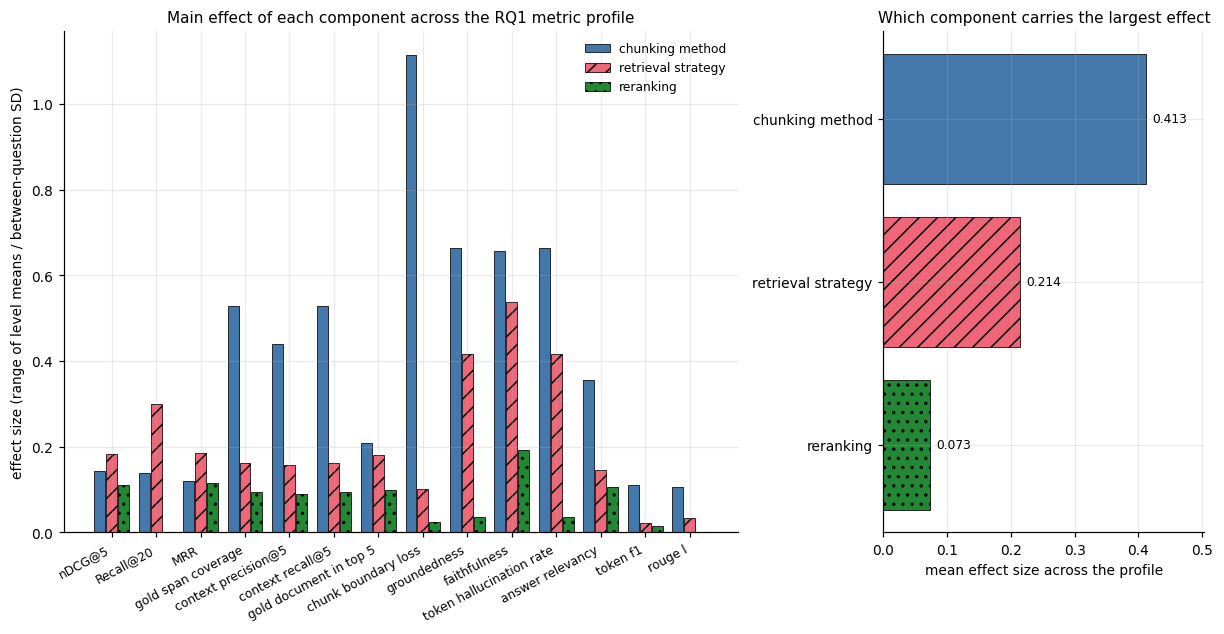

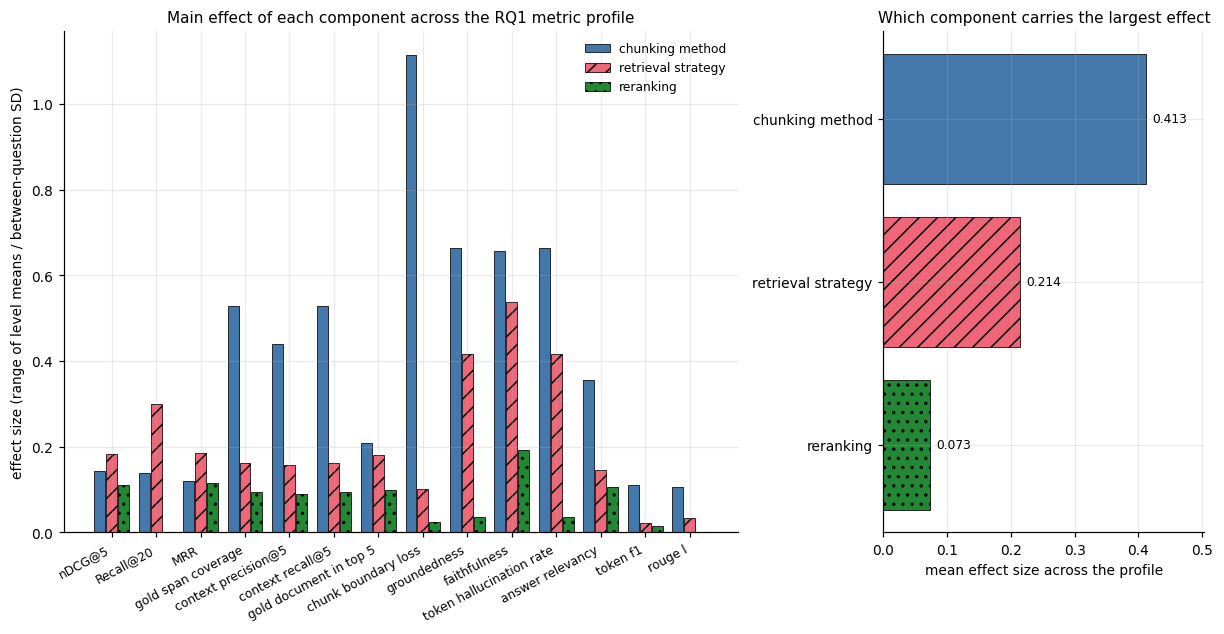

In [5]:
C.plot_effect_sizes(effects, PROFILE_METRICS, 'fig_rq1_main_effects',
    title='Main effect of each component across the RQ1 metric profile',
    caption='Left: the main effect of each pipeline component on each metric of the RQ1 '
            'profile, as the range of its level means divided by the between-question '
            'standard deviation. Right: the mean of those effects across the profile, which '
            'is the ranking that answers RQ1.')

## 5. The whole profile in one table

,factor,level,n,nDCG@5,Recall@20,MRR,gold_span_coverage,context_precision@5,context_recall@5,gold_document_in_top_5,chunk_boundary_loss,groundedness,faithfulness,token_hallucination_rate,answer_relevancy,token_f1,rouge_l
0,chunking_method,fixed_window,610,0.5673,0.8361,0.5506,0.6439,0.1298,0.6439,0.6672,0.0246,0.7805,0.7516,0.2195,0.8908,0.0943,0.0830
1,chunking_method,late_chunking,610,0.6031,0.8508,0.5825,0.6882,0.1390,0.6882,0.7049,0.0180,0.7677,0.7299,0.2323,0.8835,0.1034,0.0881
2,chunking_method,recursive_structure,610,0.5685,0.8328,0.5533,0.6230,0.1256,0.6230,0.6672,0.0443,0.7528,0.6969,0.2472,0.8994,0.0888,0.0754
3,chunking_method,semantic_breakpoint,610,0.5434,0.8049,0.5340,0.4647,0.1007,0.4647,0.6148,0.1672,0.7729,0.7560,0.2271,0.8817,0.0972,0.0809
4,chunking_method,sliding_window,610,0.5693,0.8246,0.5530,0.6436,0.1298,0.6436,0.6672,0.0262,0.7724,0.7410,0.2276,0.8951,0.0915,0.0793
5,retrieval_strategy,bm25,610,0.4987,0.7213,0.4827,0.5780,0.1170,0.5780,0.5902,0.0148,0.7891,0.7519,0.2109,0.9007,0.0893,0.0752
6,retrieval_strategy,dense,610,0.5693,0.8246,0.5530,0.6436,0.1298,0.6436,0.6672,0.0262,0.7724,0.7410,0.2276,0.8951,0.0915,0.0793
7,retrieval_strategy,hybrid_rrf,610,0.5429,0.8262,0.5318,0.6165,0.1236,0.6165,0.6328,0.0197,0.7293,0.6867,0.2707,0.8910,0.0901,0.0755
8,retrieval_strategy,hybrid_weighted,610,0.5726,0.8033,0.5559,0.6476,0.1308,0.6476,0.6623,0.0180,0.7697,0.7156,0.2303,0.9080,0.0886,0.0753
9,reranking,cross_encoder,610,0.5243,0.8246,0.5077,0.6016,0.1216,0.6016,0.6246,0.0230,0.7794,0.7319,0.2206,0.8958,0.0895,0.0792


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_full_profile.csv
  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_profile_heatmap.png


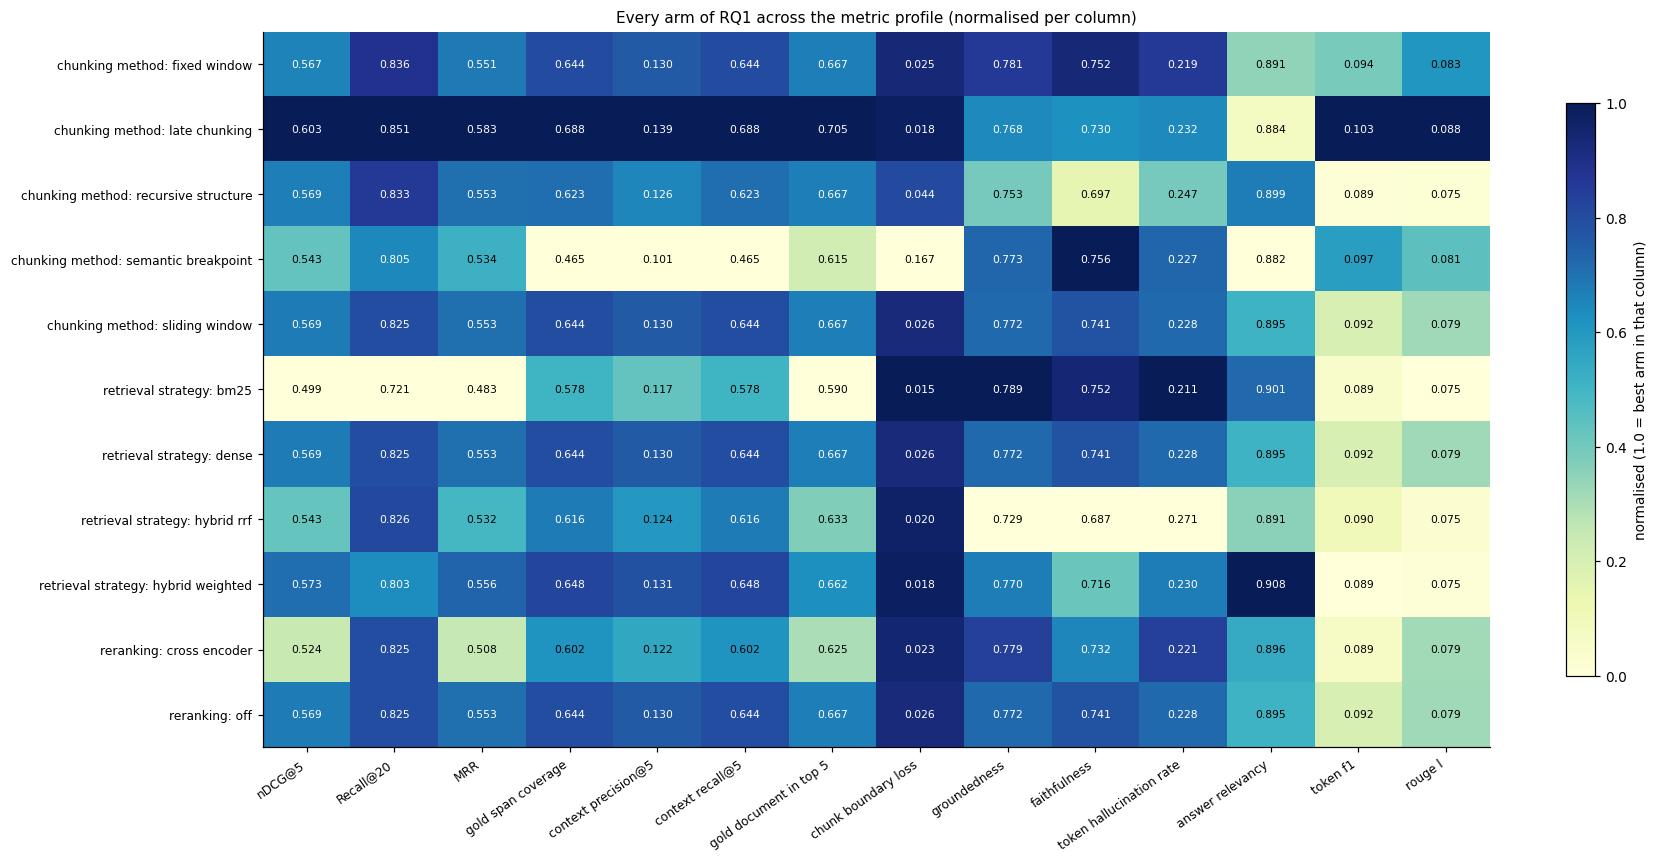

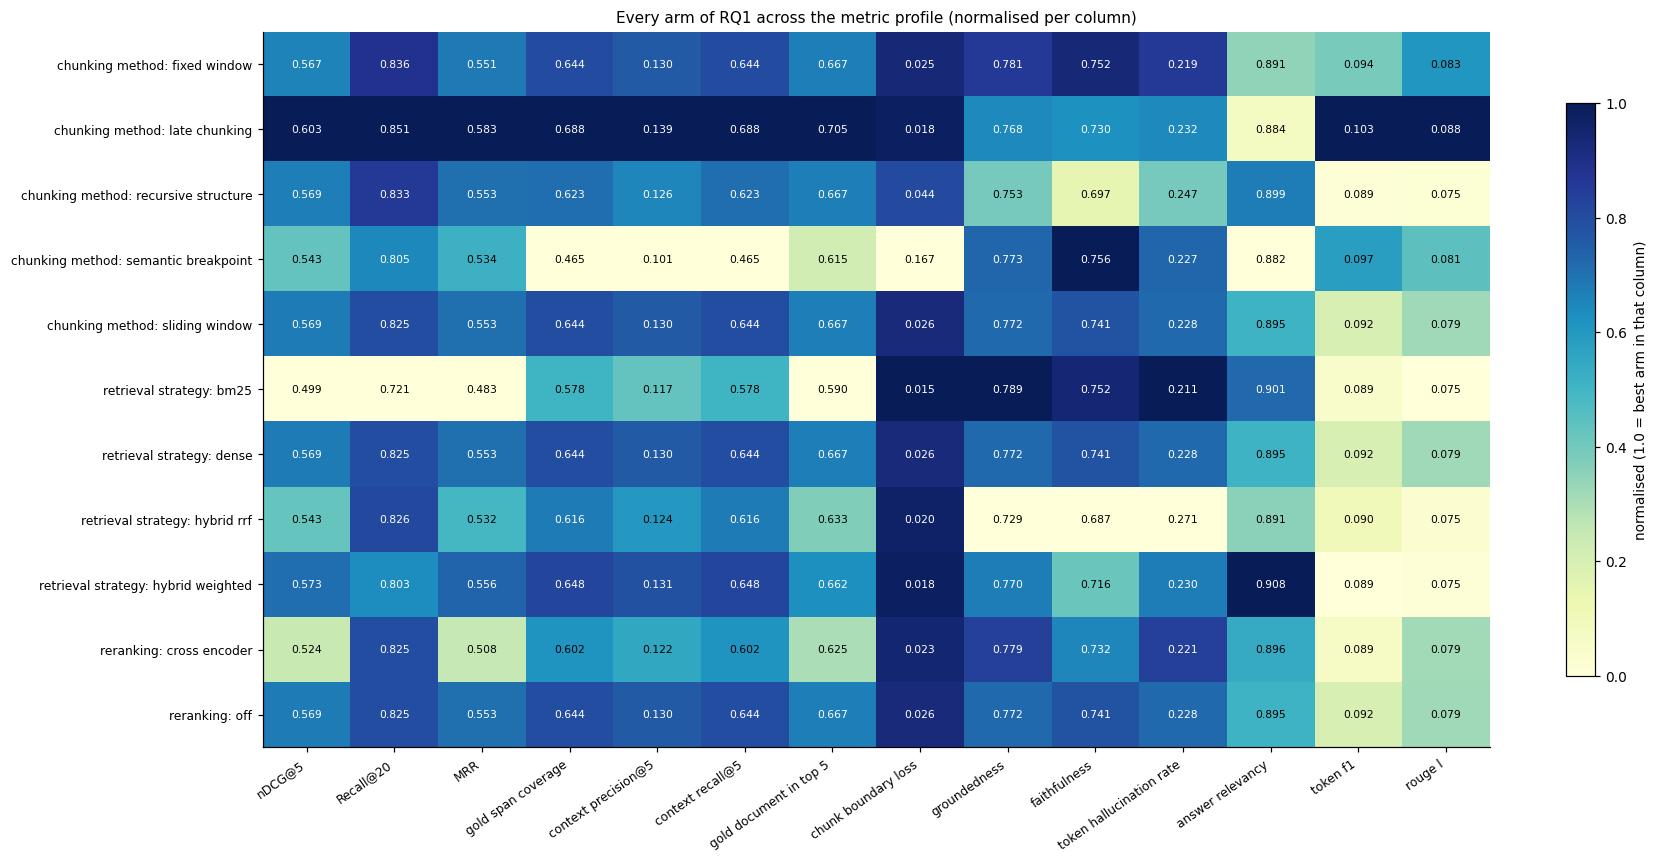

In [6]:
rows = []
for factor, (df, col) in frames.items():
    s = C.arm_summary(df, [col], PROFILE_METRICS)
    s = s.rename(columns={col: 'level'})
    s.insert(0, 'factor', factor)
    rows.append(s)
profile = pd.concat(rows, ignore_index=True)
profile['arm'] = profile.factor.str.replace('_', ' ') + ': ' + profile.level.astype(str)
display(profile[['factor', 'level', 'n'] + PROFILE_METRICS].round(4))
C.save_table(profile, 'rq1_full_profile')
C.plot_heatmap(profile, 'arm', PROFILE_METRICS, 'fig_rq1_profile_heatmap',
    'Every arm of RQ1 across the metric profile (normalised per column)',
    caption='Every level of every RQ1 factor across the metric profile. Each column is '
            'min-max normalised in the direction of improvement, so 1.0 is always the best '
            'arm in that column; printed values are the raw means.')

## 6. The answer to RQ1

Every number below is read from the computed results. Nothing here is typed by hand.

In [7]:
answer = C.answer_rq1(effects, ranking, headline_metric='nDCG@5')
answer['matched_ordering'] = list(matched.factor)
answer['orderings_agree'] = bool(agree)
answer['profile_metrics'] = PROFILE_METRICS
answer['n_questions_retrieval'] = int(A.question_id.nunique())
answer['n_questions_generation'] = int(G.question_id.nunique()) if G is not None else 0
answer['generation_profile'] = (C.load_results('rq1_generation') or {}).get('profile')
C.save_results(answer, 'rq1_answer')

top = answer['largest_main_effect']
print('=' * 92)
print('RQ1: which component carries the largest main effect?')
print('=' * 92)
print(f"\n  {top.replace('_',' ').upper()}, with a mean standardised effect of "
      f"{answer['largest_main_effect_statistic']:.3f} across "
      f"{len(PROFILE_METRICS)} metrics.")
print(f"  Runner-up: {str(answer['runner_up']).replace('_',' ')} at "
      f"{answer['runner_up_statistic']:.3f} (margin {answer['margin']:.3f}).")
print(f"  It carries the largest effect on {answer['metrics_won'].get(top, 0)} of "
      f"{len(PROFILE_METRICS)} metrics.")
print(f"  Level-count-independent check: {'same ordering' if agree else 'DIFFERENT ordering'}.")
print('\n  On nDCG@5 specifically:')
for h in answer['headline_order']:
    star = '*' if h['p_holm'] is not None and h['p_holm'] < 0.05 else ' '
    print(f"    {star} {h['factor']:<20} range {h['range']:.4f} "
          f"[{h['range_ci'][0]:.4f}, {h['range_ci'][1]:.4f}]  "
          f"eta2 {h['eta2_partial']:.4f}  best: {h['best_level']}")
print('\n  * = significant after Holm correction across factors')

  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_answer.json
RQ1: which component carries the largest main effect?

  CHUNKING METHOD, with a mean standardised effect of 0.413 across 14 metrics.
  Runner-up: retrieval strategy at 0.214 (margin 0.198).
  It carries the largest effect on 11 of 14 metrics.
  Level-count-independent check: same ordering.

  On nDCG@5 specifically:
    * retrieval_strategy   range 0.0739 [0.0539, 0.1051]  eta2 0.0245  best: hybrid_weighted
    * chunking_method      range 0.0598 [0.0343, 0.0858]  eta2 0.0152  best: late_chunking
    * reranking            range 0.0450 [0.0157, 0.0733]  eta2 0.0156  best: off

  * = significant after Holm correction across factors


## 7. The numbers the write-up needs

This writes `rq1_report_numbers.json` and a Markdown draft of the results section with every value substituted from the computed results. Download both; the local script `insert_rq1_into_report.py` turns them into the Chapter 5 section.

In [8]:
def m(factor, metric, col='range'):
    r = effects[(effects.factor == factor) & (effects.metric == metric)]
    return float(r[col].iloc[0]) if len(r) else float('nan')

numbers = {
    'answer': answer,
    'effects': effects.to_dict(orient='records'),
    'ranking': ranking.to_dict(orient='records'),
    'matched': matched.to_dict(orient='records'),
    'profile': profile.to_dict(orient='records'),
    'contrasts': {
        'chunking':  C.load_records('rq1_factorA_contrasts'),
        'retrieval': C.load_records('rq1_factorB_contrasts'),
        'reranking': C.load_records('rq1_factorC_contrasts'),
    },
    'late_chunking':    C.load_records('rq1_factorA_late_chunking'),
    'complementarity':  C.load_results('rq1_factorB_complementarity'),
    'promotion':        C.load_results('rq1_factorC_promotion'),
    'chunk_statistics': C.load_records('rq1_chunk_statistics'),
    'cost': {
        'build':      C.load_records('rq1_build_cost'),
        'factorA':    C.load_records('rq1_factorA_cost'),
        'factorB':    C.load_records('rq1_factorB_cost'),
        'factorC':    C.load_records('rq1_factorC_cost'),
        'generation': C.load_records('rq1_generation_cost'),
    },
    'abstention':         C.load_records('rq1_abstention'),
    'readability':        C.load_records('rq1_readability'),
    'generation_summary': {f: C.load_records(f'rq1_generation_summary_{f}')
                           for f in ('chunking_method', 'retrieval_strategy', 'reranking')},
    'dataset':            C.load_results('e1_dataset_validation'),
    'reproduction_check': C.load_records('rq1_factorB_reproduction_check'),
    'figures': sorted(p.name for p in C.PATHS.FIG.glob('fig_rq1_*.png')),
    'provenance': C.stamp({'stage': 'synthesis'}),
}
C.save_results(numbers, 'rq1_report_numbers')
print('\nDownload these two files and the figures folder:')
print(' ', C.PATHS.OUT / 'rq1_report_numbers.json')
print(' ', C.PATHS.OUT / 'rq1_answer.json')
print(' ', C.PATHS.FIG)

  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_report_numbers.json

Download these two files and the figures folder:
  /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_report_numbers.json
  /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_answer.json
  /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures


In [9]:
# Zip everything the write-up needs into one download.
import shutil
bundle = C.PATHS.ROOT / 'rq1_results_bundle'
shutil.make_archive(str(bundle), 'zip', str(C.PATHS.OUT))
print('bundle:', str(bundle) + '.zip',
      f'({(bundle.with_suffix(".zip")).stat().st_size/1024**2:.1f} MB)')
try:
    from google.colab import files
    files.download(str(bundle) + '.zip')
except Exception as e:
    print('download it from the Drive folder instead:', e)

bundle: /content/drive/MyDrive/techqa_rq1/rq1_results_bundle.zip (4.5 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>